In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/home/rodrigo/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

2026-05-25 16:55:33.868712: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-25 16:55:34.062385: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779738934.105259   31228 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779738934.118389   31228 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779738934.502423   31228 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
Ytrain  = pd.read_pickle('../data/ytrain.pkl')
Ytest   = pd.read_pickle('../data/ytest.pkl')

Xtrain  = pd.read_pickle('../data/xtrain.pkl')
Xtest   = pd.read_pickle('../data/xtest.pkl')

In [4]:
scaler = MinMaxScaler()


Xtrain_norm = scaler.fit_transform(Xtrain)
Xtest_norm = scaler.fit_transform(Xtest)

Ytrain_dummy = pd.get_dummies(Ytrain, dtype=np.float32)
Ytest_dummy = pd.get_dummies(Ytest, dtype=np.float32)

#tf.keras.utils.to_categorical também faz a mesma coisa
#Ytrain_dummy2 = tf.keras.utils.to_categorical(Ytrain, num_classes=4)

In [32]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[21]),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(10, activation="relu"),
    keras.layers.Dense(3, activation="softmax")
])

/home/rodrigo/.local/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │         2,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,793 (30.44 KB)

 Trainable params: 7,793 (30.44 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.compile(loss="categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [ ]:
history = model.fit(Xtrain_norm, Ytrain_dummy, epochs=300, validation_split=0.1)

Epoch 1/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6583 - loss: 0.9622 - val_accuracy: 0.7812 - val_loss: 0.7453
Epoch 2/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7666 - loss: 0.7498 - val_accuracy: 0.7812 - val_loss: 0.6478
Epoch 3/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7910 - loss: 0.6368 - val_accuracy: 0.7812 - val_loss: 0.6076
Epoch 4/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7876 - loss: 0.6071 - val_accuracy: 0.7812 - val_loss: 0.5787
Epoch 5/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7913 - loss: 0.5762 - val_accuracy: 0.7812 - val_loss: 0.5541
Epoch 6/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7931 - loss: 0.5516 - val_accuracy: 0.7812 - val_loss: 0.5292
Epoch 7/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7760 - loss: 0.5519 - val_accuracy: 0.7865 - val_loss: 0.5065
Epoch 8/300
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7862 - loss: 0.5108 - val_accuracy: 0.8021 - v

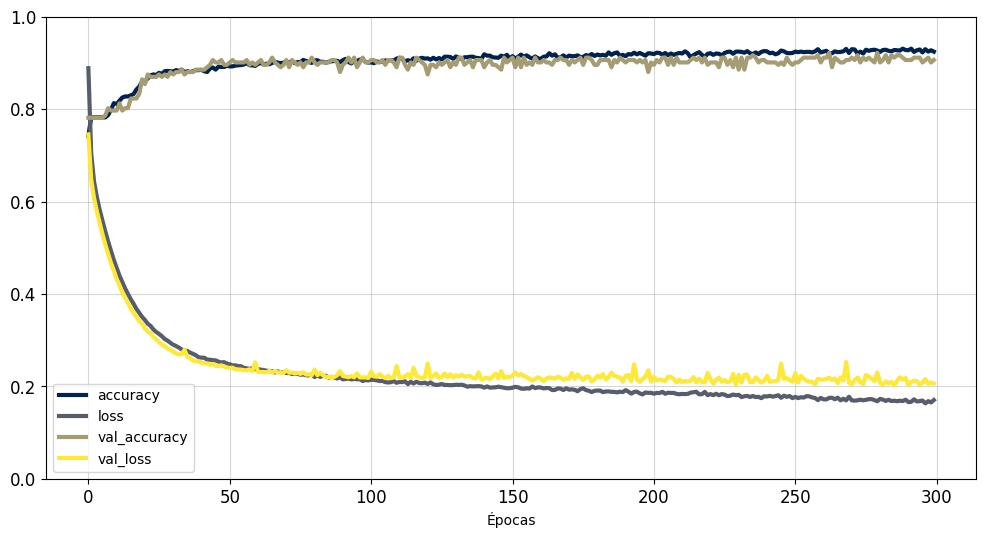

In [48]:
pd.DataFrame(history.history).plot(figsize=(12,6), colormap='cividis', linewidth = 3)
plt.grid(True, alpha = 0.5)
plt.gca().set_ylim(0, 1)
plt.xlabel("Épocas")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('../results/treinoRedeNeuralComScaler.png')
plt.show()

In [58]:
model.evaluate(Xtest_norm, Ytest_dummy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8704 - loss: 0.2793 


[0.32147133350372314, 0.8591549396514893]

In [80]:
ypred = model.predict(Xtest)
ypred = pd.DataFrame(ypred.astype(int))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [84]:
ypred

,0,1,2
0,0,0,0
1,0,0,1
2,0,0,1
3,0,1,0
4,0,0,1
...,...,...,...
208,0,0,1
209,0,0,1
210,0,0,1
211,0,1,0


In [91]:
ypredNotDummy = pd.DataFrame({
    'valor': ypred.values.argmax(axis=1) + 1
})

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

In [106]:
fresults = open('../results/classificationMetricsRedeNeura.txt', 'w+')
print(classification_report(Ytest, ypredNotDummy).replace("      ", "&"))
fresults.write(classification_report(Ytest, ypredNotDummy))

fresults.close()


&&  precision    recall  f1-score   support

&     1& 0.88&0.13&0.23& 159
&     2& 0.08&0.14&0.10&  36
&     3& 0.15&1.00&0.26&  18

    accuracy&&&&   0.21& 213
   macro avg& 0.37&0.42&0.19& 213
weighted avg& 0.68&0.21&0.21& 213



<Figure size 800x800 with 0 Axes>

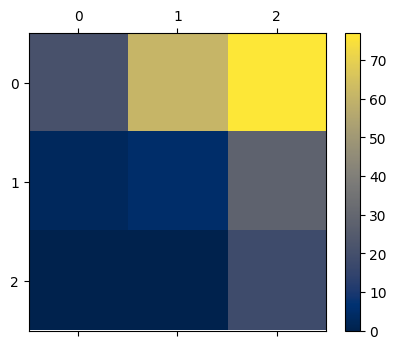

In [101]:
conf_matrix = confusion_matrix(Ytest, ypredNotDummy)

plt.figure(figsize=(8, 8))
plt.matshow(conf_matrix, cmap='cividis')
plt.colorbar(shrink=0.8)
plt.savefig('../results/ConfMatrixRedeNeural.png')
plt.show()

<Figure size 800x600 with 0 Axes>

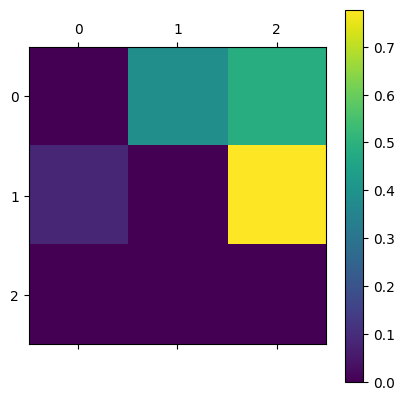

In [103]:
row_sums = conf_matrix.sum(axis=1, keepdims=True)
norm_conf_mx = conf_matrix / row_sums
np.fill_diagonal(norm_conf_mx, 0)
plt.figure(figsize=(8,6))
plt.matshow(norm_conf_mx)
plt.colorbar()
plt.savefig('../results/relativeConfMatrixRedeNeural.png')
plt.show()

In [102]:
conf_matrix

array([[21, 61, 77],
       [ 3,  5, 28],
       [ 0,  0, 18]])